# Notebook 20 -- Wu 2003 Model Verification

This notebook is the first executable checkpoint for the Wu 2003
CSTR-column-recycle extension described in
[`../project_wu2003_sbi.md`](../project_wu2003_sbi.md).

The purpose here is deliberately narrow: verify that the deterministic
physics layer in `cstr_sbi.recycle` has the right nominal scale and the
right qualitative closed-loop fault signatures before generating data or
training SBI posteriors.

We check:

1. the Arrhenius back-calculation gives `k(T_ss) ~= 0.33 /h`,
2. the QSS column returns nominally plausible `x_D`, `x_B`, and recycle flow,
3. the closed-loop steady state sits near the Wu 2003 operating point,
4. catalyst decay increases recycle flow through the snowball mechanism, and
5. jacket fouling is masked in reactor temperature but visible in jacket duty.


## 1. Imports and constants

The notebook uses only the current `cstr_sbi.recycle` implementation:
`physics.py` for the ODE and QSS column, and `scenarios.py` for the W1-W16
fault table. Later notebooks will add stochastic simulation, summaries,
and inference.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cstr_sbi.recycle.physics import (
    ALPHA_REL,
    CP_MOLAR,
    D_FRAC_NOM,
    EA,
    F0_NOM,
    F_B_NOM,
    F_R_NOM,
    K0,
    K_SS,
    MJ_CPJ,
    NOMINAL_CTRL,
    NOMINAL_INLET,
    NOMINAL_THETA,
    NOMINAL_Y0,
    PARAM_NAMES,
    QJ_NOM,
    R_GAS,
    T_J_NOM,
    T_SP,
    T_SS,
    UA_NOM,
    X_B_NOM,
    X_D_NOM,
    Z0_NOM,
    column_qss,
    compute_qj,
    extract_observations,
    simulate_to_steady_state,
    simulate_trajectory,
)
from cstr_sbi.recycle.scenarios import list_closed_loop_configs, list_open_loop_configs

pd.set_option("display.precision", 5)

print("JAX devices:", jax.devices())
print()
print("Nominal degradation vector:")
print(dict(zip(PARAM_NAMES, np.asarray(NOMINAL_THETA))))
print()
print(f"T_sp / T_ss = {T_SP:.3f} K")
print(f"T_j_nom     = {T_J_NOM:.3f} K")
print(f"Q_j_nom     = {QJ_NOM:.3e} Btu/h")
print(f"UA_nom      = {UA_NOM:.3e} Btu/(h K)")
print(f"Cp_molar    = {CP_MOLAR:.3f} Btu/(lbmol K)")
print(f"M_j Cp_j    = {MJ_CPJ:.3f} Btu/K")

JAX devices: [CpuDevice(id=0)]

Nominal degradation vector:
{'alpha': np.float32(1.0), 'beta_r': np.float32(1.0), 'eta_col': np.float32(1.0), 'xi_reb': np.float32(1.0), 'z_A0_eff': np.float32(0.9)}

T_sp / T_ss = 342.261 K
T_j_nom     = 330.983 K
Q_j_nom     = 9.351e+06 Btu/h
UA_nom      = 8.687e+05 Btu/(h K)
Cp_molar    = 126.000 Btu/(lbmol K)
M_j Cp_j    = 44939.000 Btu/K


## 2. Kinetics sanity check

Wu 2003 gives the rate constant at the reactor steady-state temperature as
`k_ss = 0.33 /h`. The implementation stores Kelvin temperatures and uses
`R_GAS = 3.576 Btu/(lbmol K)`, converted from the Rankine convention.

The check below is the first acceptance criterion for nb20.


In [2]:
def k_of_T(T):
    return K0 * np.exp(-EA / (R_GAS * T))

k_at_ss = k_of_T(T_SS)
kinetics = pd.DataFrame([
    {"quantity": "T_SS", "value": T_SS, "target": 342.26, "units": "K"},
    {"quantity": "K0", "value": K0, "target": np.nan, "units": "1/h"},
    {"quantity": "k(T_SS)", "value": k_at_ss, "target": K_SS, "units": "1/h"},
    {"quantity": "relative error in k", "value": (k_at_ss - K_SS) / K_SS, "target": 0.0, "units": "fraction"},
])
kinetics


,quantity,value,target,units
0,T_SS,3.42261e+02,342.26,K
1,K0,2.91000e+10,NaN,1/h
2,k(T_SS),3.31403e-01,0.33,1/h
3,relative error in k,4.25130e-03,0.00,fraction


## 3. QSS column at the nominal reactor composition

The QSS column is currently implemented as a fast McCabe-Thiele style
algebraic closure. For the nominal reactor outlet composition we expect
roughly the published Wu 2003 distillate composition, bottoms composition,
and recycle/product split.


In [3]:
z_nom = float(NOMINAL_Y0[0])
x_D, x_B, D_frac = column_qss(jnp.array(z_nom), jnp.array(1.0))
x_D = float(x_D)
x_B = float(x_B)
D_frac = float(D_frac)
F_total = F0_NOM / (1.0 - D_frac)
F_R = D_frac * F_total
F_B = F_total - F_R

column_check = pd.DataFrame([
    {"quantity": "z_F nominal IC", "value": z_nom, "target": np.nan, "units": "mol/mol A"},
    {"quantity": "x_D", "value": x_D, "target": X_D_NOM, "units": "mol/mol A"},
    {"quantity": "x_B", "value": x_B, "target": X_B_NOM, "units": "mol/mol A"},
    {"quantity": "D/F", "value": D_frac, "target": D_FRAC_NOM, "units": "fraction"},
    {"quantity": "F_R", "value": F_R, "target": F_R_NOM, "units": "lbmol/h"},
    {"quantity": "F_B", "value": F_B, "target": F_B_NOM, "units": "lbmol/h"},
])
column_check


,quantity,value,target,units
0,z_F nominal IC,0.50800,NaN,mol/mol A
1,x_D,0.96577,0.95000,mol/mol A
2,x_B,0.01050,0.01050,mol/mol A
3,D/F,0.52079,0.52103,fraction
4,F_R,499.91912,500.40000,lbmol/h
5,F_B,460.00000,460.00000,lbmol/h


## 4. Scenario catalogue

The Wu extension uses a 5-D degradation vector
`[alpha, beta_r, eta_col, xi_reb, z_A0_eff]`.

For nb20 we only run deterministic step tests, but the catalogue below previews
the scenario set that nb21/nb22 will use. The display is intentionally compact:
closed-loop scenarios are the main fault-design grid, and open-loop cases are
diagnostic counterparts used to show which effects are masked by feedback.


In [4]:
def scenario_frame(configs):
    rows = []
    for sc in configs:
        fault_tags = []
        if sc.alpha != 1.0:
            fault_tags.append("alpha")
        if sc.beta_r != 1.0:
            fault_tags.append("beta_r")
        if sc.eta_col != 1.0:
            fault_tags.append("eta_col")
        if sc.xi_reb != 1.0:
            fault_tags.append("xi_reb")
        if sc.z_A0_eff != float(Z0_NOM):
            fault_tags.append("z_A0")
        rows.append({
            "id": sc.id,
            "scenario": sc.name,
            "mode": sc.mode,
            "fault_tags": "+".join(fault_tags) if fault_tags else "healthy",
            "alpha": sc.alpha,
            "beta_r": sc.beta_r,
            "eta_col": sc.eta_col,
            "xi_reb": sc.xi_reb,
            "z_A0_eff": sc.z_A0_eff,
        })
    return pd.DataFrame(rows).set_index("id")


closed_loop_df = scenario_frame(list_closed_loop_configs())
open_loop_df = scenario_frame(list_open_loop_configs())

print(f"Closed-loop scenarios: {len(closed_loop_df)}")
print(f"Open-loop diagnostic counterparts: {len(open_loop_df)}")
print()
print("Open-loop cases currently implemented:", ", ".join(open_loop_df["scenario"].tolist()))

display(closed_loop_df)
display(open_loop_df)


Closed-loop scenarios: 16
Open-loop diagnostic counterparts: 7

Open-loop cases currently implemented: W1_healthy_ol, W2_cat_decay_ol, W3_rxr_fouling_ol, W4_col_tray_eff_ol, W5_reb_starve_ol, W11_snowball_ol, W15_severe_multi_ol


,scenario,mode,fault_tags,alpha,beta_r,eta_col,xi_reb,z_A0_eff
id,,,,,,,,
1,W1_healthy,closed_loop,healthy,1.00,1.00,1.00,1.00,0.90
2,W2_cat_decay,closed_loop,alpha,0.65,1.00,1.00,1.00,0.90
3,W3_rxr_fouling,closed_loop,beta_r,1.00,0.65,1.00,1.00,0.90
4,W4_col_tray_eff,closed_loop,eta_col,1.00,1.00,0.70,1.00,0.90
5,W5_reb_starve,closed_loop,xi_reb,1.00,1.00,1.00,0.65,0.90
6,W6_feed_lean,closed_loop,z_A0,1.00,1.00,1.00,1.00,0.75
7,W7_feed_rich,closed_loop,z_A0,1.00,1.00,1.00,1.00,0.95
8,W8_mild_cat,closed_loop,alpha,0.80,1.00,1.00,1.00,0.90
9,W9_mild_fouling,closed_loop,beta_r,1.00,0.80,1.00,1.00,0.90


,scenario,mode,fault_tags,alpha,beta_r,eta_col,xi_reb,z_A0_eff
id,,,,,,,,
101,W1_healthy_ol,open_loop,healthy,1.00,1.00,1.00,1.00,0.9
102,W2_cat_decay_ol,open_loop,alpha,0.65,1.00,1.00,1.00,0.9
103,W3_rxr_fouling_ol,open_loop,beta_r,1.00,0.65,1.00,1.00,0.9
104,W4_col_tray_eff_ol,open_loop,eta_col,1.00,1.00,0.70,1.00,0.9
105,W5_reb_starve_ol,open_loop,xi_reb,1.00,1.00,1.00,0.65,0.9
111,W11_snowball_ol,open_loop,alpha+eta_col,0.65,1.00,0.75,1.00,0.9
115,W15_severe_multi_ol,open_loop,alpha+beta_r+eta_col,0.60,0.70,0.70,1.00,0.9


**Open-loop note.** The written plan says "W2-OL through W8-OL", while
the current code catalogue implements seven diagnostic open-loop cases:
`W1`, `W2`, `W3`, `W4`, `W5`, `W11`, and `W15`. Before nb22 data generation,
the project should either update `scenarios.py` to exactly match the written
W2-W8 set, or revise the plan text to match this more targeted open-loop set.


## 5. Closed-loop nominal steady state

We integrate the 4-state recycle ODE to steady state from the nominal warm
initial condition. The trajectory should stay near `T_sp`, with the recycle
loop returning a flow scale close to Wu 2003 Table 1.


In [5]:
y_ss = simulate_to_steady_state(
    NOMINAL_THETA,
    NOMINAL_INLET,
    NOMINAL_CTRL,
    NOMINAL_Y0,
    t_final=200.0,
)
y_ss_np = np.asarray(y_ss)

obs_ss = np.asarray(extract_observations(y_ss[None, :], NOMINAL_THETA, NOMINAL_CTRL))[0]
z_A_ss, T_r_ss, T_j_ss, I_T_ss = y_ss_np
z_A_obs, T_r_obs, T_j_obs, Q_j_obs, x_D_obs, x_B_obs, F_R_norm_obs = obs_ss[:7]
F_R_obs = F_R_norm_obs * F_R_NOM

ss_table = pd.DataFrame([
    {"quantity": "z_A reactor", "value": z_A_ss, "target": np.nan, "units": "mol/mol A"},
    {"quantity": "T_r", "value": T_r_ss, "target": T_SP, "units": "K"},
    {"quantity": "T_j", "value": T_j_ss, "target": T_J_NOM, "units": "K"},
    {"quantity": "I_T", "value": I_T_ss, "target": 0.0, "units": "K h"},
    {"quantity": "Q_j", "value": Q_j_obs, "target": QJ_NOM, "units": "Btu/h"},
    {"quantity": "x_D", "value": x_D_obs, "target": X_D_NOM, "units": "mol/mol A"},
    {"quantity": "x_B", "value": x_B_obs, "target": X_B_NOM, "units": "mol/mol A"},
    {"quantity": "F_R", "value": F_R_obs, "target": F_R_NOM, "units": "lbmol/h"},
])
ss_table


,quantity,value,target,units
0,z_A reactor,5.13775e-01,NaN,mol/mol A
1,T_r,3.42279e+02,3.42261e+02,K
2,T_j,3.31351e+02,3.30983e+02,K
3,I_T,3.47017e+00,0.00000e+00,K h
4,Q_j,9.49117e+06,9.35100e+06,Btu/h
5,x_D,9.75579e-01,9.50000e-01,mol/mol A
6,x_B,1.05000e-02,1.05000e-02,mol/mol A
7,F_R,5.01309e+02,5.00400e+02,lbmol/h


## 6. Catalyst decay step: snowball signature

The plan's first dynamic acceptance test is a catalyst activity drop from
`alpha = 1.0` to `alpha = 0.65` under closed-loop operation. Conversion falls,
more A reaches the column, and recycle flow should rise. That increasing
recycle flow is the snowball signature.


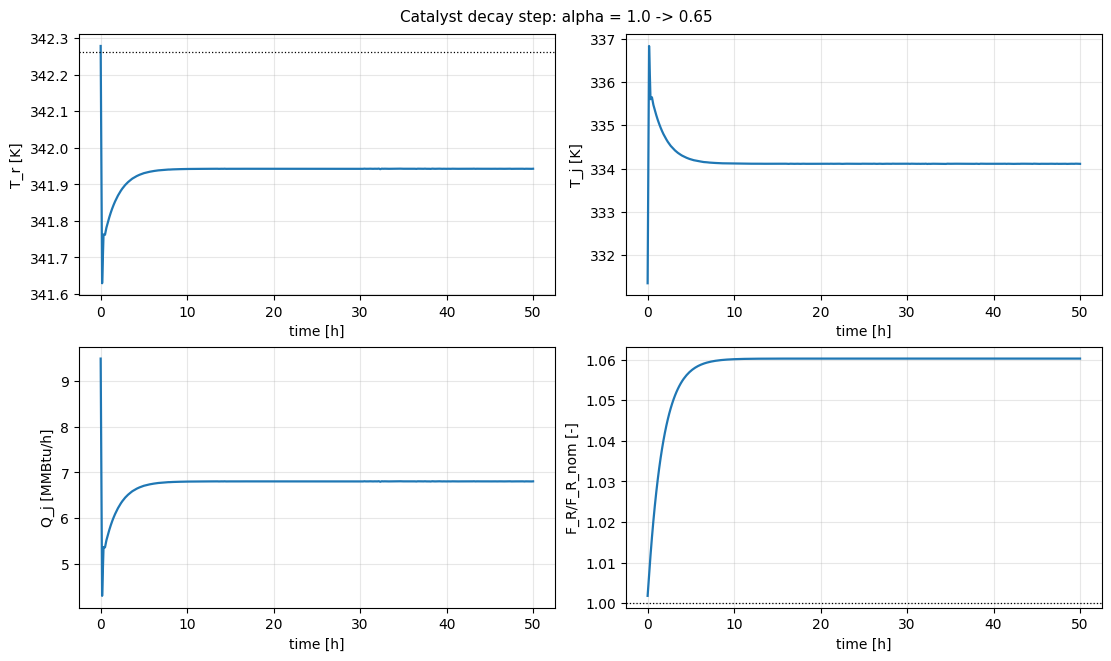

,metric,value
0,F_R/F_R_nom initial,1.00182
1,F_R/F_R_nom final,1.06026
2,recycle change [%],5.83369
3,T_r final - T_sp [K],-0.31833
4,Q_j final / Q_j_nom,0.72765


In [6]:
theta_cat = NOMINAL_THETA.at[0].set(0.65)
t_cat, y_cat = simulate_trajectory(
    theta_cat,
    NOMINAL_INLET,
    NOMINAL_CTRL,
    y_ss,
    t_final=50.0,
    n_save=301,
)
obs_cat = np.asarray(extract_observations(y_cat, theta_cat, NOMINAL_CTRL))
t_cat = np.asarray(t_cat)
y_cat = np.asarray(y_cat)

cat_channels = {
    "T_r [K]": obs_cat[:, 1],
    "T_j [K]": obs_cat[:, 2],
    "Q_j [MMBtu/h]": obs_cat[:, 3] / 1e6,
    "F_R/F_R_nom [-]": obs_cat[:, 6],
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for ax, (label, values) in zip(axes.ravel(), cat_channels.items()):
    ax.plot(t_cat, values, lw=1.6)
    ax.set_xlabel("time [h]")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
axes[0, 0].axhline(T_SP, color="k", ls=":", lw=0.9)
axes[1, 1].axhline(1.0, color="k", ls=":", lw=0.9)
fig.suptitle("Catalyst decay step: alpha = 1.0 -> 0.65", fontsize=11)
plt.show()

cat_summary = pd.DataFrame([
    {"metric": "F_R/F_R_nom initial", "value": obs_cat[0, 6]},
    {"metric": "F_R/F_R_nom final", "value": obs_cat[-1, 6]},
    {"metric": "recycle change [%]", "value": 100.0 * (obs_cat[-1, 6] / obs_cat[0, 6] - 1.0)},
    {"metric": "T_r final - T_sp [K]", "value": obs_cat[-1, 1] - T_SP},
    {"metric": "Q_j final / Q_j_nom", "value": obs_cat[-1, 3] / QJ_NOM},
])
cat_summary


## 7. Jacket fouling step: temperature masking

The second dynamic acceptance test is a reactor jacket fouling step from
`beta_r = 1.0` to `beta_r = 0.60`. The reactor temperature loop should keep
`T_r` close to setpoint, while the controller compensation appears in `Q_j`
and the jacket temperature response.


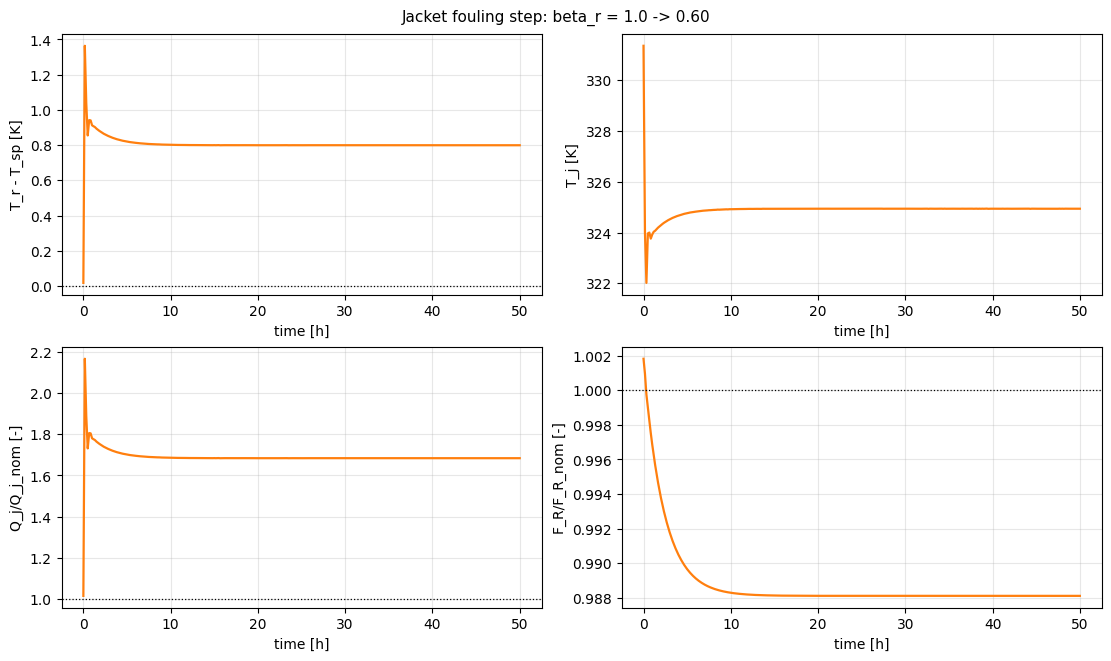

,metric,value
0,max |T_r - T_sp| [K],1.36368
1,final T_r - T_sp [K],0.79901
2,T_j initial [K],331.35123
3,T_j final [K],324.93640
4,Q_j/Q_j_nom initial,1.01499
5,Q_j/Q_j_nom final,1.68362


In [7]:
theta_foul = NOMINAL_THETA.at[1].set(0.60)
t_foul, y_foul = simulate_trajectory(
    theta_foul,
    NOMINAL_INLET,
    NOMINAL_CTRL,
    y_ss,
    t_final=50.0,
    n_save=301,
)
obs_foul = np.asarray(extract_observations(y_foul, theta_foul, NOMINAL_CTRL))
t_foul = np.asarray(t_foul)
y_foul = np.asarray(y_foul)

foul_channels = {
    "T_r - T_sp [K]": obs_foul[:, 1] - T_SP,
    "T_j [K]": obs_foul[:, 2],
    "Q_j/Q_j_nom [-]": obs_foul[:, 3] / QJ_NOM,
    "F_R/F_R_nom [-]": obs_foul[:, 6],
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for ax, (label, values) in zip(axes.ravel(), foul_channels.items()):
    ax.plot(t_foul, values, lw=1.6, color="C1")
    ax.set_xlabel("time [h]")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
axes[0, 0].axhline(0.0, color="k", ls=":", lw=0.9)
axes[1, 0].axhline(1.0, color="k", ls=":", lw=0.9)
axes[1, 1].axhline(1.0, color="k", ls=":", lw=0.9)
fig.suptitle("Jacket fouling step: beta_r = 1.0 -> 0.60", fontsize=11)
plt.show()

foul_summary = pd.DataFrame([
    {"metric": "max |T_r - T_sp| [K]", "value": np.max(np.abs(obs_foul[:, 1] - T_SP))},
    {"metric": "final T_r - T_sp [K]", "value": obs_foul[-1, 1] - T_SP},
    {"metric": "T_j initial [K]", "value": obs_foul[0, 2]},
    {"metric": "T_j final [K]", "value": obs_foul[-1, 2]},
    {"metric": "Q_j/Q_j_nom initial", "value": obs_foul[0, 3] / QJ_NOM},
    {"metric": "Q_j/Q_j_nom final", "value": obs_foul[-1, 3] / QJ_NOM},
])
foul_summary


## 8. Side-by-side fault signatures

This comparison is the practical reason nb20 exists. The same temperature
controller can make `T_r` look deceptively stable, so the later SBI study must
learn from controller outputs and recycle-loop signals, not from reactor
temperature alone.


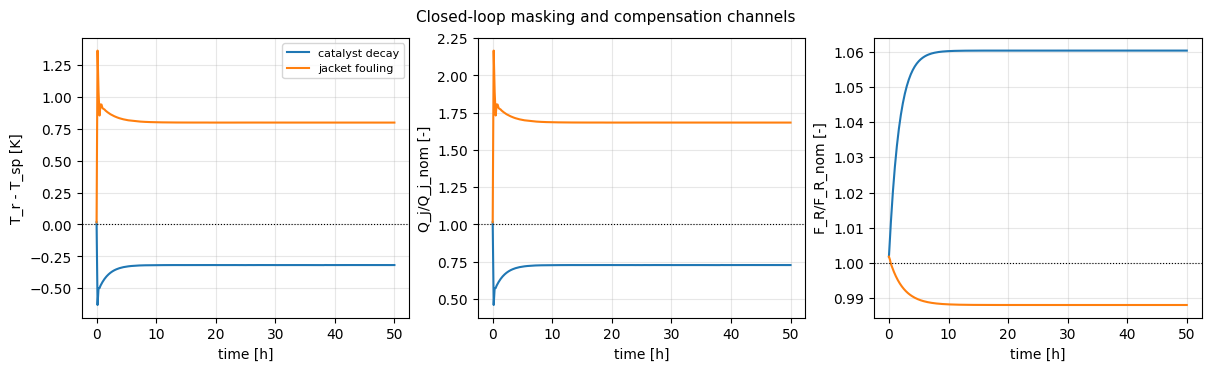

,case,final_T_error_K,final_Qj_ratio,final_FR_ratio,FR_change_pct
0,catalyst decay alpha=0.65,-0.31833,0.72765,1.06026,5.83369
1,jacket fouling beta_r=0.60,0.79901,1.68362,0.98811,-1.36847


In [8]:
comparison = [
    ("catalyst decay", t_cat, obs_cat, "C0"),
    ("jacket fouling", t_foul, obs_foul, "C1"),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for label, t, obs, color in comparison:
    axes[0].plot(t, obs[:, 1] - T_SP, lw=1.5, label=label, color=color)
    axes[1].plot(t, obs[:, 3] / QJ_NOM, lw=1.5, label=label, color=color)
    axes[2].plot(t, obs[:, 6], lw=1.5, label=label, color=color)

axes[0].axhline(0.0, color="k", ls=":", lw=0.8)
axes[1].axhline(1.0, color="k", ls=":", lw=0.8)
axes[2].axhline(1.0, color="k", ls=":", lw=0.8)
axes[0].set_ylabel("T_r - T_sp [K]")
axes[1].set_ylabel("Q_j/Q_j_nom [-]")
axes[2].set_ylabel("F_R/F_R_nom [-]")
for ax in axes:
    ax.set_xlabel("time [h]")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Closed-loop masking and compensation channels", fontsize=11)
plt.show()

pd.DataFrame([
    {
        "case": "catalyst decay alpha=0.65",
        "final_T_error_K": obs_cat[-1, 1] - T_SP,
        "final_Qj_ratio": obs_cat[-1, 3] / QJ_NOM,
        "final_FR_ratio": obs_cat[-1, 6],
        "FR_change_pct": 100.0 * (obs_cat[-1, 6] / obs_cat[0, 6] - 1.0),
    },
    {
        "case": "jacket fouling beta_r=0.60",
        "final_T_error_K": obs_foul[-1, 1] - T_SP,
        "final_Qj_ratio": obs_foul[-1, 3] / QJ_NOM,
        "final_FR_ratio": obs_foul[-1, 6],
        "FR_change_pct": 100.0 * (obs_foul[-1, 6] / obs_foul[0, 6] - 1.0),
    },
])


## 9. Automated acceptance check

The table below compares the executed notebook results against the nb20
expectations from the project plan. This is intentionally stricter than
"the notebook ran": it checks whether the model behavior matches the planned
scientific acceptance criteria.


In [9]:
def verdict(condition):
    return "PASS" if bool(condition) else "FAIL"

kinetics_rel_err = abs((k_at_ss - K_SS) / K_SS)
col_xD_abs_err = abs(x_D_obs - X_D_NOM)
col_xB_abs_err = abs(x_B_obs - X_B_NOM)
col_FR_abs_err = abs(F_R_obs - F_R_NOM)
ss_Tr_abs_err = abs(T_r_ss - T_SP)
cat_FR_change_pct = 100.0 * (obs_cat[-1, 6] / obs_cat[0, 6] - 1.0)
cat_Tr_final_err = obs_cat[-1, 1] - T_SP
foul_max_Tr_abs_err = np.max(np.abs(obs_foul[:, 1] - T_SP))
foul_Tj_change = obs_foul[-1, 2] - obs_foul[0, 2]
foul_Qj_ratio_change = obs_foul[-1, 3] / obs_foul[0, 3] - 1.0

checks = [
    {
        "plan_check": "k0 back-calculation",
        "expected": "k(T_ss) ~= 0.33 /h",
        "observed": f"k={k_at_ss:.5f}/h, rel_err={kinetics_rel_err:.3%}",
        "status": verdict(kinetics_rel_err < 0.01),
        "note": "within 1% tolerance",
    },
    {
        "plan_check": "QSS column nominal x_D",
        "expected": "x_D close to 0.95",
        "observed": f"x_D={x_D_obs:.5f}, abs_err={col_xD_abs_err:.5f}",
        "status": verdict(col_xD_abs_err < 0.03),
        "note": "within shortcut-column tolerance for nb20",
    },
    {
        "plan_check": "QSS column nominal x_B",
        "expected": "x_B close to 0.0105",
        "observed": f"x_B={x_B_obs:.5f}, abs_err={col_xB_abs_err:.5f}",
        "status": verdict(col_xB_abs_err < 0.002),
        "note": "bottoms impurity target is recovered",
    },
    {
        "plan_check": "QSS column nominal F_R",
        "expected": "F_R close to 500.4 lbmol/h",
        "observed": f"F_R={F_R_obs:.2f} lbmol/h, abs_err={col_FR_abs_err:.3f}",
        "status": verdict(col_FR_abs_err < 1.0),
        "note": "flow split matches nominal scale",
    },
    {
        "plan_check": "closed-loop nominal steady state",
        "expected": "T_r near 342.2 K",
        "observed": f"T_r={T_r_ss:.4f} K, abs_err={ss_Tr_abs_err:.5f} K",
        "status": verdict(ss_Tr_abs_err < 0.1),
        "note": "reactor temperature setpoint is recovered",
    },
    {
        "plan_check": "alpha step snowball",
        "expected": "F_R increases clearly after alpha=0.65 step",
        "observed": f"F_R change={cat_FR_change_pct:.5f}%, final T_error={cat_Tr_final_err:.3f} K",
        "status": verdict(cat_FR_change_pct > 5.0),
        "note": "composition-responsive recycle split produces snowball onset",
    },
    {
        "plan_check": "beta_r step temperature masking",
        "expected": "T_r stays near setpoint after beta_r=0.60 step",
        "observed": f"max |T_r-T_sp|={foul_max_Tr_abs_err:.5f} K",
        "status": verdict(foul_max_Tr_abs_err < 2.0),
        "note": "small transient; final regulation is recovered",
    },
    {
        "plan_check": "beta_r step compensation signals",
        "expected": "T_j and Q_j change after beta_r=0.60 step",
        "observed": f"Delta T_j={foul_Tj_change:.3f} K, Delta Q_j/Q_j0={foul_Qj_ratio_change:.5%}",
        "status": verdict(abs(foul_Tj_change) > 1.0 and abs(foul_Qj_ratio_change) > 0.05),
        "note": "jacket and controller compensation signals are visible",
    },
]

acceptance = pd.DataFrame(checks)
acceptance


,plan_check,expected,observed,status,note
0,k0 back-calculation,k(T_ss) ~= 0.33 /h,"k=0.33140/h, rel_err=0.425%",PASS,within 1% tolerance
1,QSS column nominal x_D,x_D close to 0.95,"x_D=0.97558, abs_err=0.02558",PASS,within shortcut-column tolerance for nb20
2,QSS column nominal x_B,x_B close to 0.0105,"x_B=0.01050, abs_err=0.00000",PASS,bottoms impurity target is recovered
3,QSS column nominal F_R,F_R close to 500.4 lbmol/h,"F_R=501.31 lbmol/h, abs_err=0.909",PASS,flow split matches nominal scale
4,closed-loop nominal steady state,T_r near 342.2 K,"T_r=342.2786 K, abs_err=0.01752 K",PASS,reactor temperature setpoint is recovered
5,alpha step snowball,F_R increases clearly after alpha=0.65 step,"F_R change=5.83369%, final T_error=-0.318 K",PASS,composition-responsive recycle split produces ...
6,beta_r step temperature masking,T_r stays near setpoint after beta_r=0.60 step,max |T_r-T_sp|=1.36368 K,PASS,small transient; final regulation is recovered
7,beta_r step compensation signals,T_j and Q_j change after beta_r=0.60 step,"Delta T_j=-6.415 K, Delta Q_j/Q_j0=65.87549%",PASS,jacket and controller compensation signals are...


## 10. Interpretation

Notebook execution is technically clean and the nb20 scientific acceptance
checks pass at the shortcut-model verification level.

The reactor-temperature masking seen in the `beta_r` step is **expected**, not
a defect. This is the same closed-loop identifiability mechanism documented in
notebooks 14 and 15: the PI loop pins the controlled variable near setpoint,
so fouling information is displaced from `T_r` into compensation channels such
as `T_j` and `Q_j`. In the original PO study, that masking produces the
structural beta-bias / low-Fisher-information result; in the Wu 2003 extension,
nb20 only verifies that the same closed-loop topology is present.

The two required qualitative signatures are now present: catalyst decay creates
a recycle-flow increase through the snowball closure, and jacket fouling keeps
`T_r` nearly regulated while `T_j` and `Q_j` move. The next notebook (`nb21`)
can therefore focus on separating the S-A and S-B control structures and adding
the remaining plant-wide observables (`T_reb`, `Q_reb`, and product flow).
